In [2]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point

from matplotlib import pyplot as plt
import matplotlib as mpl
import seaborn as sns
import missingno

In [3]:
data = pd.read_csv('data/raw/05_FMBA24sf2_clean_250620_n3754.csv', sep='\t')
metadata = pd.read_csv('data/raw/05_FMBA24sf2_meta_250620.csv', sep='\t')
metadata = metadata.set_index('colname')

## Look at the data

First we will look at what data we have. What kind of variables, how many samples, and how complete is the data. We have some information about the variables in the metadata file. 

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3754 entries, 0 to 3753
Columns: 180 entries, fmba_campaign_year to geometry
dtypes: bool(6), float64(69), int64(2), object(103)
memory usage: 5.0+ MB


In [5]:
# Look at the columns
data.iloc[:,:100].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3754 entries, 0 to 3753
Data columns (total 100 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   fmba_campaign_year           3754 non-null   int64  
 1   FRMRgender                   3754 non-null   object 
 2   FRMRregion                   3754 non-null   object 
 3   FRMRdistrict                 3754 non-null   object 
 4   FRMRward                     3754 non-null   object 
 5   previousadvice               3754 non-null   object 
 6   mainharvestcrop              3754 non-null   object 
 7   minorharvestcrop             50 non-null     object 
 8   crophistory                  3754 non-null   object 
 9   crophistory_cropnumber       3754 non-null   int64  
 10  crophistory_intercrop        298 non-null    object 
 11  fieldslope                   3754 non-null   object 
 12  landscape                    3754 non-null   object 
 13  soil_texture     

In [6]:
data.iloc[:, 100:].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3754 entries, 0 to 3753
Data columns (total 80 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   numsoyadiseases               638 non-null    float64
 1   soyaresidues                  638 non-null    object 
 2   othermaincrop_harvestmeasure  135 non-null    object 
 3   minorcrop_harvestmeasure      32 non-null     object 
 4   herbicides                    2 non-null      object 
 5   weedings                      2 non-null      float64
 6   manurefreq                    3754 non-null   object 
 7   manure                        3754 non-null   object 
 8   fertiliser_use                3754 non-null   object 
 9   basal_application             1493 non-null   object 
 10  basaltypes                    1051 non-null   object 
 11  KGbasal_ha                    985 non-null    float64
 12  KGNbasal_ha                   985 non-null    float64
 13  KGP

### Treatment

It seems that the `previousadvice` variable can be considered as the treatment. Let's look at the metadata of that column.

In [7]:
treatment_varname = 'previousadvice'
metadata.loc[treatment_varname]

colindex                                                      6
coltype                                               character
n_distinct                                                    2
n_missing                                                     0
mean                                                        NaN
median                                                      NaN
min                                                         NaN
max                                                         NaN
type                                                 select_one
values                                                 yes / no
questn        Advice with phone last season?\r\r\nWas Farmer...
Name: previousadvice, dtype: object

Now, the data is collected through a survey, so let's see what what that variable is the answer to.

In [8]:
metadata.loc[treatment_varname, 'questn']

'Advice with phone last season?\r\r\nWas Farmer-MBA advice given to you for the 2023-24 season?'

In [9]:
data.previousadvice.value_counts()

previousadvice
no     3109
yes     645
Name: count, dtype: int64

It seems that most of the farmers on the dataset did not receive an advice. However, there is still some things we don't know about the advice and what was done with it. **Was it just provided or did they actually followed it? At what point in the season was it provided?**

### Missing data

Missigno allows us to visualize and analyze missing data.

<Axes: >

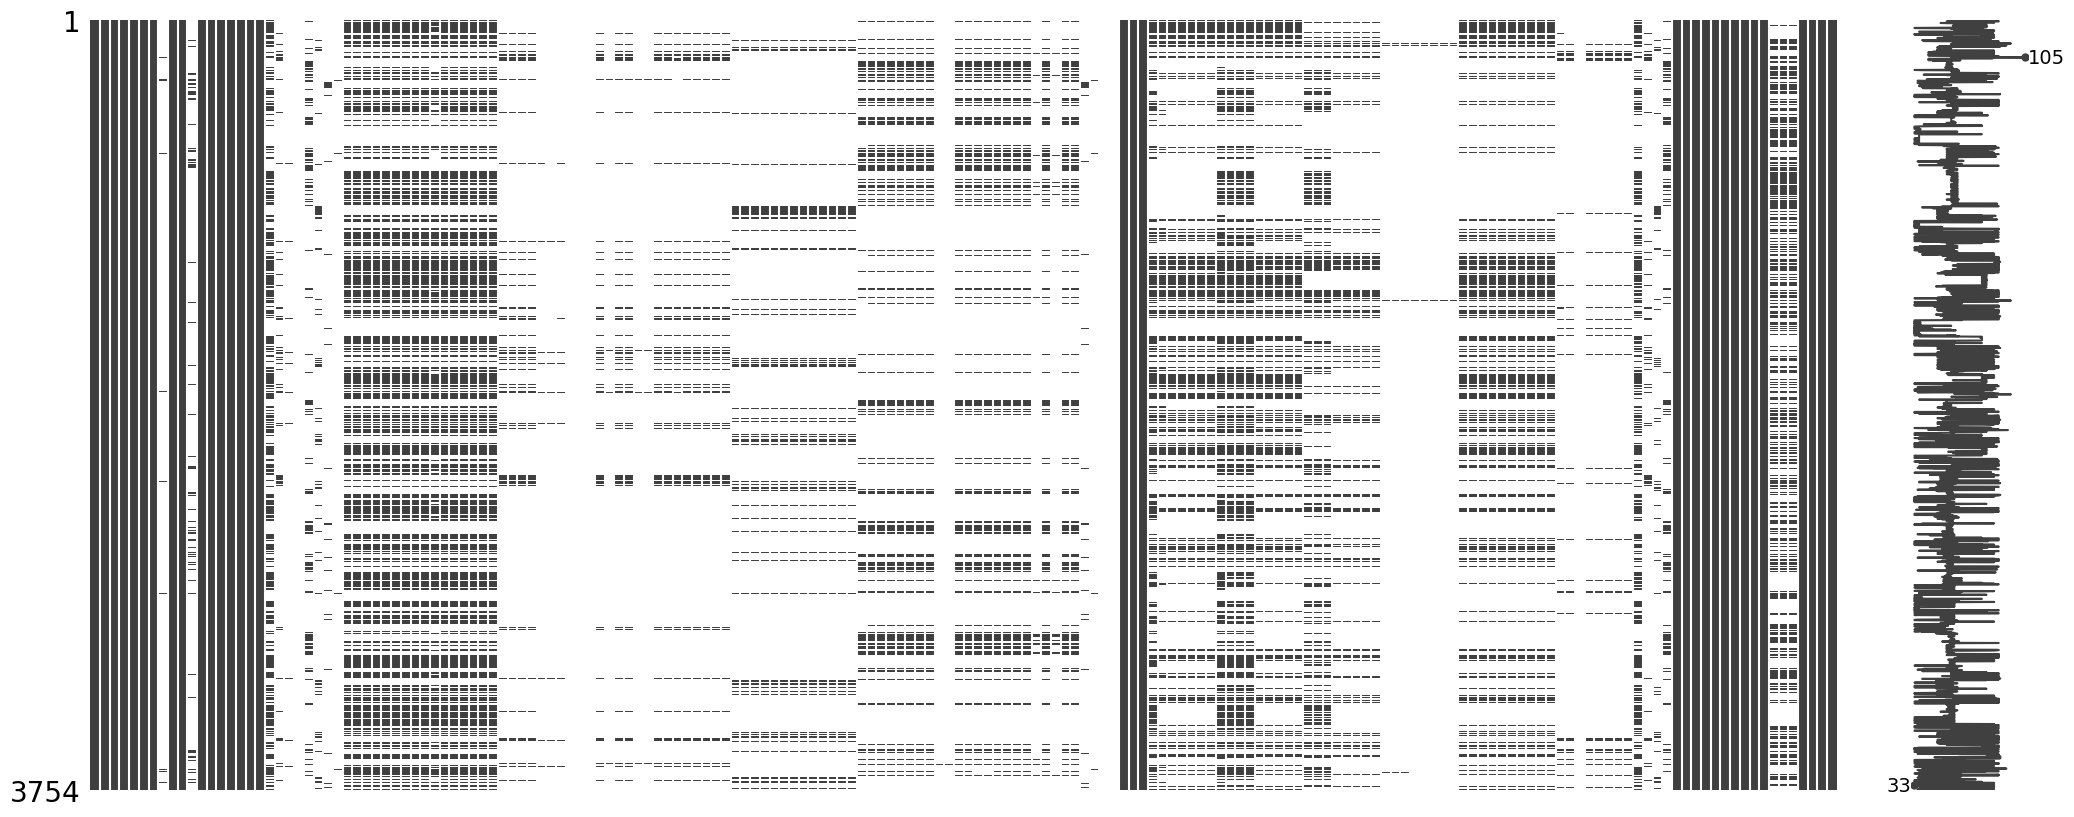

In [10]:
missingno.matrix(data)

### Crop production data
There are some clusters of data. We will see later that those clusters are specific crops. The `mainharvestcrop` variable indicates what is the main the main crop for the survey respondent. Let's take a look at what are the most common crops:

In [11]:
data.mainharvestcrop.value_counts()

mainharvestcrop
maize            1940
soya              634
no_crop           437
groundnuts        320
beans             219
dontknow           71
sunflower          66
roundpotatoes      24
pigeonpea          20
sweetpotatoes      17
cassava             3
coffee              1
fingermillet        1
vegetables          1
Name: count, dtype: int64

### Spatial distribution of the samples

There are some point coordinates in the `geometry` column. However, we don't know what is the CRS. For the magnitude of the coordinates, it makes sense to think that it's a CRS in meters. So after looking at the CRS for that region, the EPSG:32736 is the CRS that makes more sense. 

Now we will plot the location of the samples. The admin3 unit is reported in the survey on the `FRMRward` column. We can check if the reported coordinates in the selected CRS coincide with the admin3 units reported.

In [12]:
crs = 'EPSG:32736'
gdf = gpd.read_file('data/geo/tza_shp/tza_admbnda_adm3_20181019.shp')
gdf = gdf.to_crs(crs)
boundary = gpd.GeoSeries(gdf.union_all().boundary)

In [13]:
# Create a geodf with the data.
points = gpd.GeoDataFrame(
    geometry=[
        Point(lon, lat) for lon, lat in 
        data.geometry.map(lambda x: tuple(map(float, x[2:-1].split(','))))
    ],
    crs=crs
)
# Save to inspect in qgis. This geojson is used by the scripts to extract soil and weather data
points.join(data.drop('geometry', axis=1)).to_file('data/geo/points.geojson')

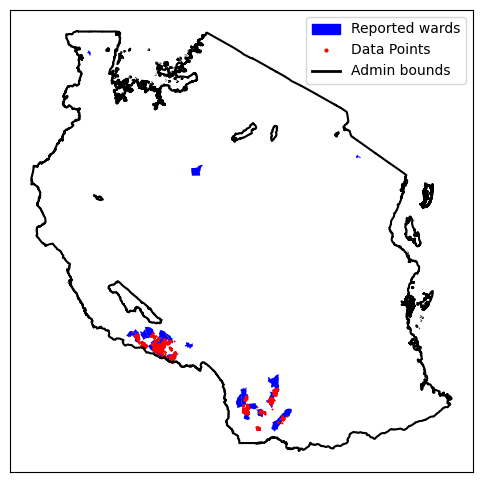

In [17]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
gdf.loc[gdf.ADM3_EN.isin(data.FRMRward.unique())].plot(ax=ax, color='b')
points.plot(
    ax=ax, marker= 'o', linewidth=0, markersize=2,
    color='r'
)
boundary.plot(ax=ax, color='k')
ax.legend(handles=[
    mpl.patches.Patch(color='b', label='Reported wards'),
    mpl.lines.Line2D([], [], color='r', marker='o', linestyle='None',
                           markersize=2, label='Data Points'),
    mpl.lines.Line2D([], [], color='k', linestyle='-',
                         linewidth=2, label='Admin bounds')
])
ax.set_xticks([]); ax.set_yticks([]);
# ax.set_xlim(.3e6, .9e6)
# ax.set_ylim(8.75e6, 9.05e6)

We see that there are some wards that seem to be reported in the survey, but there are not points in those wards. There are also wards reported on the survey that are not in the country geometries:

In [14]:
# Wards reported on survey but not in geometry
set(data.FRMRward.unique()) - set(gdf.ADM3_EN)

{'Chapwa',
 'Idiwili',
 'Ikana',
 'Keselia',
 'Kilimampimbi',
 'Mahenje',
 'Matimila',
 'Mhukuru',
 'Msampanya',
 'Ndalambo',
 'Nyimbili',
 'Otherward',
 'Ukwile'}

That can happen for a lot of reasons. They can misspell the name. Administrative boundaries and names change with time. We don't know if the shapefile we have does reflect the names that people use for a place. For example, "Chapwa" is a village within a ward with a different name, but that is the name reported on the survey. 

Those differences on the data are not important now. So far, we see that the reported points are within most of the reported admin units, then it is safe to say that the CRS we define for the data must be alright.

## Group the variables

We saw that we have data that reflects different crops. The reponder of the survey reports the data for their main crop. There are many variables that are crop specific. We will here find those variables by going over the metadata.

Overall, we identified a group of variables that reflects the field and responder characteristics. There is also a group of variables associated to fertilizer management. There are groups of variables for four main crops: maize, groundnuts, soya, and beans.

In [15]:
field_columns = [
    'fmba_campaign_year', 'FRMRgender', 'FRMRregion', 'FRMRdistrict',
    'FRMRward', 'previousadvice', 'mainharvestcrop', 'minorharvestcrop',
    'crophistory', 'crophistory_cropnumber', 'crophistory_intercrop',
    'fieldslope', 'landscape', 'soil_texture', 'est_harvestarea_ha',
    'gpsharvestarea_corrected_ha', 'area_diff_m2', 'harvestarea_ha',
    # Residues refer to last season, that's why it goes on field data
    'maizeresidues', 'beansresidues', 'gnutsresidues', 'soyaresidues', 

    'instanceID', 'surveyDate', 'start', 'end', 'PHONEmodel', 'PHONEcode', 
    'fieldID', 'is_revisit', 'is_splitted', 'is_duplicated', 'n_overlap',
    'id_unique', 'id_cross', 'is_duplicated_multiple', 'is_duplicated_saved',
    'is_tiny_area', 'geometry'
]
maize_columns = [
    'maizeprodkg_ha', 'maizemarketing',
    'maizeharvest_seperate', 'maizeharvestsheller', 'maizevariety',
    'maizerecycledseed', 'maizefieldprep', 'maizeplantingmethod',
    'maizeplantmonth', 'maizeplantmonthpart', 'maizedryplant',
    'maizePdeficiency', 'maizeKdeficiency', 'maizeherbicides',
    'maizeweedings', 'maizepestdisease', 'maizekgseed_ha'
]
beans_columns = [
    'beans1prodkg_ha', 'beans1plantmonth', 'beans1plantmonthpart',
    'beans1_harvestmeasure', 'beansvariety1', 'beans1marketing', 
    'beansseedsource1', ''

    'beans2prodkg_ha', 'beans2plantmonth', 'beans2plantmonthpart', 
    'beans2_harvestmeasure', 'beansvariety2', 'beans2marketing', 
    'beansseedsource2', 
    
    'beans3prodkg_ha', 'beans3plantmonth', 'beans3plantmonthpart', 
    'beans3_harvestmeasure', 

    'beansfieldprep', 'beanplantingmethod', 'beansKdeficiency', 
    'beansherbicides', 'beansweedings', 'numberbeansharvests', 
    'beanspests', 'beansdiseases', 'kgbeansseed_ha',   
]
soya_columns = [
    'soyaprodkg_ha', 'soyaprodkg', 'soyavariety', 'soyaseedsource',
    'soyafieldprep', 'soyaplantingmethod', 'inoculant_awareness', 
    'inoculantfreq', 'inoculant_use', 'inoculanttype', 'inoculantpackets',
    'soyaplantmonth', 'soyaplantmonthpart', 'soyaPdeficiency', 
    'soyaKdeficiency', 'soyaherbicides', 'soyaweedings', 'soyapests',
    'soyadiseases', 'soyapesttypes', 'numsoyapests', 'soyadiseasetypes',
    'numsoyadiseases', 'kgsoyaseed_ha' 
]
gnuts_columns = [
    'gnutsprodkg_ha', 'gnuts_harvestmeasure', 'gnuts_shellstatus', 
    'gnutsmarketing', 'gnutsseedsource', 'gnutsfieldprep', 
    'gnutsplantingmethod', 'gnutsplantmonth', 'gnutplantmonthpart', 
    'gnutsherbicides', 'gnutsweedings', 'gnutspests', 'gnutsdiseases', 
    'kggnutsseed_ha',    
]
fertilizer_columns = [
    'manurefreq', 'manure', 'fertiliser_use', 'basal_application',
    'basaltypes', 'KGbasal_ha', 'KGNbasal_ha', 'KGPbasal_ha', 'KGKbasal_ha',
    'TShbasal_ha', 'topnumber', 'top1timing', 'top1application',
    'top1types', 'KGtop1_ha', 'KGNtop1_ha', 'KGPtop1_ha', 'KGKtop1_ha',
    'TShtop1_ha', 'top2timing', 'top2application', 'top2types', 'KGtop2_ha',
    'KGNtop2_ha', 'KGPtop2_ha', 'KGKtop2_ha', 'TShtop2_ha', 'top3timing',
    'top3application', 'top3types', 'KGtop3_ha', 'KGNtop3_ha', 'KGPtop3_ha',
    'KGKtop3_ha', 'TShtop3_ha', 'KGtop_ha', 'KGNtop_ha', 'KGPtop_ha',
    'KGKtop_ha', 'TShtop_ha', 'KGtotal_ha', 'KGNtotal_ha', 'KGPtotal_ha',
    'KGKtotal_ha', 'TShtotal_ha', 'nomaizefertilisers',
    'KGnomaizefertiltype1_ha', 'KGnomaizefertiltype2_ha',
    'KGnomaizefertil_ha', 'KGNnomaizefertil_ha', 'KGPnomaizefertil_ha',
    'KGKnomaizefertil_ha', 'TShnomaizefertil_ha'
]

There are a couple variables than won't be included as there are almost no reponses in such variables, or do not belong to any of the previously defined groups.

In [16]:
set(data.columns) - set(field_columns + maize_columns + soya_columns + gnuts_columns + fertilizer_columns + beans_columns)

{'herbicides',
 'minorcrop_harvestmeasure',
 'othermaincrop_harvestmeasure',
 'othermaincropprodkg_ha',
 'otherminorcropprodkg_ha',
 'weedings'}

## Include external covariates

On the `soil-data.py` and `weather-data.py` scripts we have sampled some Weather and Soil data for the sample points. In the case of soil, the soil properties for two layers (0-20, 20-50cm) are averaged for a 90mx90m area centered on the point. In the case of Weather, we have a time-series for each point from the AgERA5 dataset.

### Soil data

The soil data is saved in a df that shares the same index as the original data. We will select only the variables for the 0-20 cm layer.

In [17]:
soil_data = pd.read_pickle('data/external-covs/soil-data.pkl')
soil_vars = [
    'nitrogen_total_mean_0_20', 'clay_content_mean_0_20', 'sand_content_mean_0_20', 
    'bulk_density_mean_0_20', 'cation_exchange_capacity_mean_0_20', 
    'ph_mean_0_20', 'carbon_organic_mean_0_20'
]
soil_data = soil_data[soil_vars]
soil_data.describe()

,nitrogen_total_mean_0_20,clay_content_mean_0_20,sand_content_mean_0_20,bulk_density_mean_0_20,cation_exchange_capacity_mean_0_20,ph_mean_0_20,carbon_organic_mean_0_20
count,3754.000000,3754.000000,3754.000000,3754.000000,3754.000000,3754.000000,3754.000000
mean,66.740780,29.570147,53.278133,133.096904,25.411650,58.209051,23.753626
std,9.473174,4.293703,5.291799,5.042926,1.414689,1.363702,1.860175
min,42.000000,17.222222,40.222222,105.111111,20.000000,54.000000,18.777778
25%,60.111111,26.777778,49.777778,131.000000,24.444444,57.222222,22.444444
50%,66.666667,30.444444,52.333333,134.333333,25.333333,58.222222,23.444444
75%,73.333333,32.444444,55.777778,136.222222,26.444444,59.111111,25.000000
max,113.222222,40.777778,72.222222,146.666667,29.666667,64.000000,31.000000


### Weather data

For the case of weather data we have a timeseries for each point. We need to summarize that timeseries by creating indexes. Also, we need to determine what will be the time period to consider. For that, we can look at the survey data, and see what variables could give us a good hint on the growing season. Here, we need to focus a single crop as the growing season depends on the crop. 

We will focus on Maize. However, we will still do the operations on all the data just to keep the indexes aligned with those of the soil and Weather data. 

There are four columns that give us a hint on the growing season: `maizeplantmonth`, `maizeplantmonthpart`, `maizevariety`, and `surveyDate`

In [18]:
(
    data.loc[data.mainharvestcrop == 'maize', 'maizeplantmonth'] + ' ' +
    data.loc[data.mainharvestcrop == 'maize', 'maizeplantmonthpart'] + ' part'
).value_counts()

December first part    1039
December last part      465
November first part     154
November last part      141
January first part      117
January last part        13
February first part      10
Name: count, dtype: int64

In [19]:
data['surveyDate'] = pd.to_datetime(data.surveyDate)
data.loc[data.mainharvestcrop == 'maize', 'surveyDate'].describe()

count                             1940
mean     2024-12-07 22:35:22.886597888
min                2015-01-02 00:00:00
25%                2024-12-11 00:00:00
50%                2024-12-20 00:00:00
75%                2025-01-08 00:00:00
max                2025-02-03 00:00:00
Name: surveyDate, dtype: object

In [20]:
data.loc[data.mainharvestcrop == 'maize', 'maizevariety'].value_counts()

maizevariety
SC719                      839
PAN691                     382
SC627                      157
LOCAL_VARIETY              144
DKC9089                    115
SC403                       47
PAN53                       43
UH6303                      39
CANNOT-REMEMBER-VARIETY     22
DK777                       22
ZMS606                      20
MERU_HB513                  16
UH615                       15
PHB3253                     12
PHB30G19                    11
MERU_HB623                  10
SY6444                       8
DKC8053                      5
ZMS402                       5
PIONEER3812                  5
PAN15                        5
UNKNOWN_VARIETY              4
LUBANGO                      3
ZMS638                       2
SC513                        2
SY634                        2
SC413                        1
SC727                        1
PAN3M-01                     1
PAN4M-21                     1
Name: count, dtype: int64

We can summarize the maturity type of the varieties. The maturity type is a very important trait that defines the season length and influences the yield potential. We can create a new variable with the variety type. We define three types: early, medium, and late. This information is found on the internet, it is key information provided by the seed vendors.

In [21]:
data['maizevarietytype'] = data.maizevariety.map({ # Early 0, Medium 1, Late 2
    'SC403': 0, 'LOCAL_VARIETY': None, 'SC719': 2, 'SC627': 1, 'PAN691': 2,
    'DKC8053': 2, 'ZMS402': 0, 'DKC9089': 0, 'CANNOT-REMEMBER-VARIETY': None,
    'UNKNOWN_VARIETY': None, 'PAN53': 1, 'PIONEER3812': 1, 'UH6303': 1,
    'UH615': 1, 'LUBANGO': 0, 'PHB3253': 0, 'DK777': 1, 'PHB30G19': 1,
    'PAN15': 1, 'SY6444': 1, 'ZMS638': 1, 'MERU_HB623': 2, 'ZMS606': 1,
    'MERU_HB513': 1, 'SC413': 0, 'SC513': 0, 'SC727': 2, 'PAN3M-01': 0,
    'PAN4M-21': 0, 'SY634': 1,
})
maize_columns.append('maizevarietytype')

In [22]:
data.maizevarietytype.value_counts()

maizevarietytype
2.0    1237
1.0     345
0.0     187
Name: count, dtype: int64

Most of the varieties are long season varieties. Also most of the farmers planted in December 2023. We can consider the period December 2023 to May 2024 as the growing season. Let's also have a "critical period" from Feb to Mar. That would be the period that covers most of the late-vegetative stage, and the early-vegetative stage.

We will summarize for those two periods:
- Average mean, max, and min temperature
- Average solar radiation
- Total precipitation
- Fraction of days with rain
- Lenght of maximum dry-spell

In [23]:
# Bring the weather data
weather_data_daily = pd.read_pickle('data/external-covs/weather-data-daily-2024.pkl')
weather_data_daily.columns = ['tmean', 'tmax', 'tmin', 'vp', 'prec', 'srad', 'ws']
weather_data_daily['tmean'] -= 273.15
weather_data_daily['tmax'] -= 273.15
weather_data_daily['tmin'] -= 273.15
weather_data_daily['srad'] /= 1e6
weather_data_daily.head()

tmean       tmax       tmin         vp  prec       srad  \
0 2023-06-01  19.574219  25.269684  13.846191  14.595667  0.00  16.029400   
  2023-06-02  20.300507  25.169861  14.667847  16.436152  0.64  15.970426   
  2023-06-03  19.449982  23.837616  16.003601  17.170710  1.31  15.286976   
  2023-06-04  19.036346  23.816162  14.521667  16.215841  0.64  14.487007   
  2023-06-05  19.501221  24.512573  14.045898  16.537798  0.77  16.222376   

                    ws  
0 2023-06-01  1.581258  
  2023-06-02  1.675508  
  2023-06-03  1.865282  
  2023-06-04  1.888180  
  2023-06-05  1.887295

In [24]:
periods = {
    'season': pd.date_range('2023-12-01', '2024-05-31'),
    'critical': pd.date_range('2024-02-01', '2024-03-31')
}
rain_threshold = 1
def get_weather_vars(idx):
    tmp_df = weather_data_daily.loc[idx]
    vars_dict = {}
    for per_name, per in periods.items():
        for var in ['tmin', 'tmean', 'tmax', 'srad']:
            vars_dict[f'{per_name}_{var}'] = tmp_df[var].loc[per].mean()
        vars_dict[f'{per_name}_prec'] = tmp_df.loc[per, 'prec'].sum()
        vars_dict[f'{per_name}_rainydays'] = (tmp_df.loc[per, 'prec'] > rain_threshold).mean()
        vars_dict[f'{per_name}_maxdryspell'] = (tmp_df.loc[per, 'prec'] > rain_threshold).cumsum().value_counts().max() - 1
        vars_dict[f'{per_name}_avgdryspell'] = (tmp_df.loc[per, 'prec'] > rain_threshold).cumsum().value_counts().mean() - 1
    return vars_dict

In [25]:
weather_data = pd.DataFrame.from_dict({
    i: get_weather_vars(i)
    for i in data.index
}, orient='index')

In [26]:
weather_data.describe()

,season_tmin,season_tmean,season_tmax,season_srad,season_prec,season_rainydays,season_maxdryspell,season_avgdryspell,critical_tmin,critical_tmean,critical_tmax,critical_srad,critical_prec,critical_rainydays,critical_maxdryspell,critical_avgdryspell
count,3754.000000,3754.000000,3754.000000,3754.000000,3754.000000,3754.000000,3754.000000,3754.000000,3754.000000,3754.000000,3754.000000,3754.000000,3754.000000,3754.000000,3754.000000,3754.000000
mean,17.403847,20.652733,24.820711,17.359114,1523.268677,0.707323,22.727491,0.416558,18.009590,21.022532,25.168566,17.816273,644.218384,0.872119,3.036761,0.147580
std,1.163352,1.263213,1.400053,0.520555,206.723770,0.031320,3.020413,0.062778,1.239272,1.228742,1.374009,0.614362,72.136330,0.024666,0.753874,0.033510
min,13.790655,16.104229,19.514093,16.470100,1126.969971,0.633880,6.000000,0.326087,14.477342,16.810703,20.198404,16.844608,410.069977,0.783333,2.000000,0.090909
25%,16.526447,19.758938,23.906960,16.969654,1364.900024,0.677596,23.000000,0.365672,17.011152,20.129789,24.287252,17.382280,619.360046,0.866667,3.000000,0.132075
50%,17.523104,21.000628,25.080441,17.276897,1431.170166,0.710383,24.000000,0.407692,18.182962,21.285910,25.574568,17.612581,656.259949,0.866667,3.000000,0.153846
75%,18.184475,21.510273,25.693974,17.818674,1702.699951,0.732240,24.000000,0.475806,18.926720,21.877253,26.093071,18.431141,681.270020,0.883333,3.000000,0.153846
max,19.800058,23.336260,28.091919,18.991484,2095.500000,0.754098,26.000000,0.577586,20.546539,23.639307,28.401575,19.624277,896.869934,0.916667,8.000000,0.276596


In [27]:
data = data.join(soil_data).join(weather_data)

## Data for maize

We saw that maize is the main crop. Let's create the a separate df and look at that data.

In [44]:
weather_columns = list(weather_data.columns)
soil_columns = list(soil_data.columns)
data_maize = data[data.mainharvestcrop == 'maize'][maize_columns + fertilizer_columns + field_columns + weather_columns + soil_columns]

In [46]:
# drop columns that don't contain relevant information
columns_to_drop =[
    'fmba_campaign_year', 'FRMRregion', 'FRMRdistrict', 'FRMRward',
    'mainharvestcrop', 'minorharvestcrop', 'crophistory_intercrop',
    'beansresidues', 'gnutsresidues', 'soyaresidues', 'instanceID',
    'surveyDate', 'start', 'end', 'PHONEmodel', 'PHONEcode', 'fieldID',
    'is_splitted', 'is_duplicated', 'n_overlap', 'id_unique', 'id_cross',
    'is_duplicated_multiple', 'is_duplicated_saved', 'is_tiny_area',
    'nomaizefertilisers', 'KGnomaizefertiltype1_ha', 'KGnomaizefertiltype2_ha',
    'KGnomaizefertil_ha', 'KGNnomaizefertil_ha', 'KGPnomaizefertil_ha',
    'KGKnomaizefertil_ha', 'TShnomaizefertil_ha'
]
data_maize = data_maize.drop(columns=columns_to_drop)

In [47]:
data_maize.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1940 entries, 0 to 3753
Data columns (total 100 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   maizeprodkg_ha                      1917 non-null   float64
 1   maizemarketing                      1939 non-null   object 
 2   maizeharvest_seperate               1939 non-null   object 
 3   maizeharvestsheller                 1939 non-null   object 
 4   maizevariety                        1939 non-null   object 
 5   maizerecycledseed                   1939 non-null   object 
 6   maizefieldprep                      1939 non-null   object 
 7   maizeplantingmethod                 1939 non-null   object 
 8   maizeplantmonth                     1939 non-null   object 
 9   maizeplantmonthpart                 1939 non-null   object 
 10  maizedryplant                       1799 non-null   object 
 11  maizePdeficiency                    1939 non-nu

In [48]:
data_maize.to_pickle('data/raw/data-maize.pkl')

<Axes: >

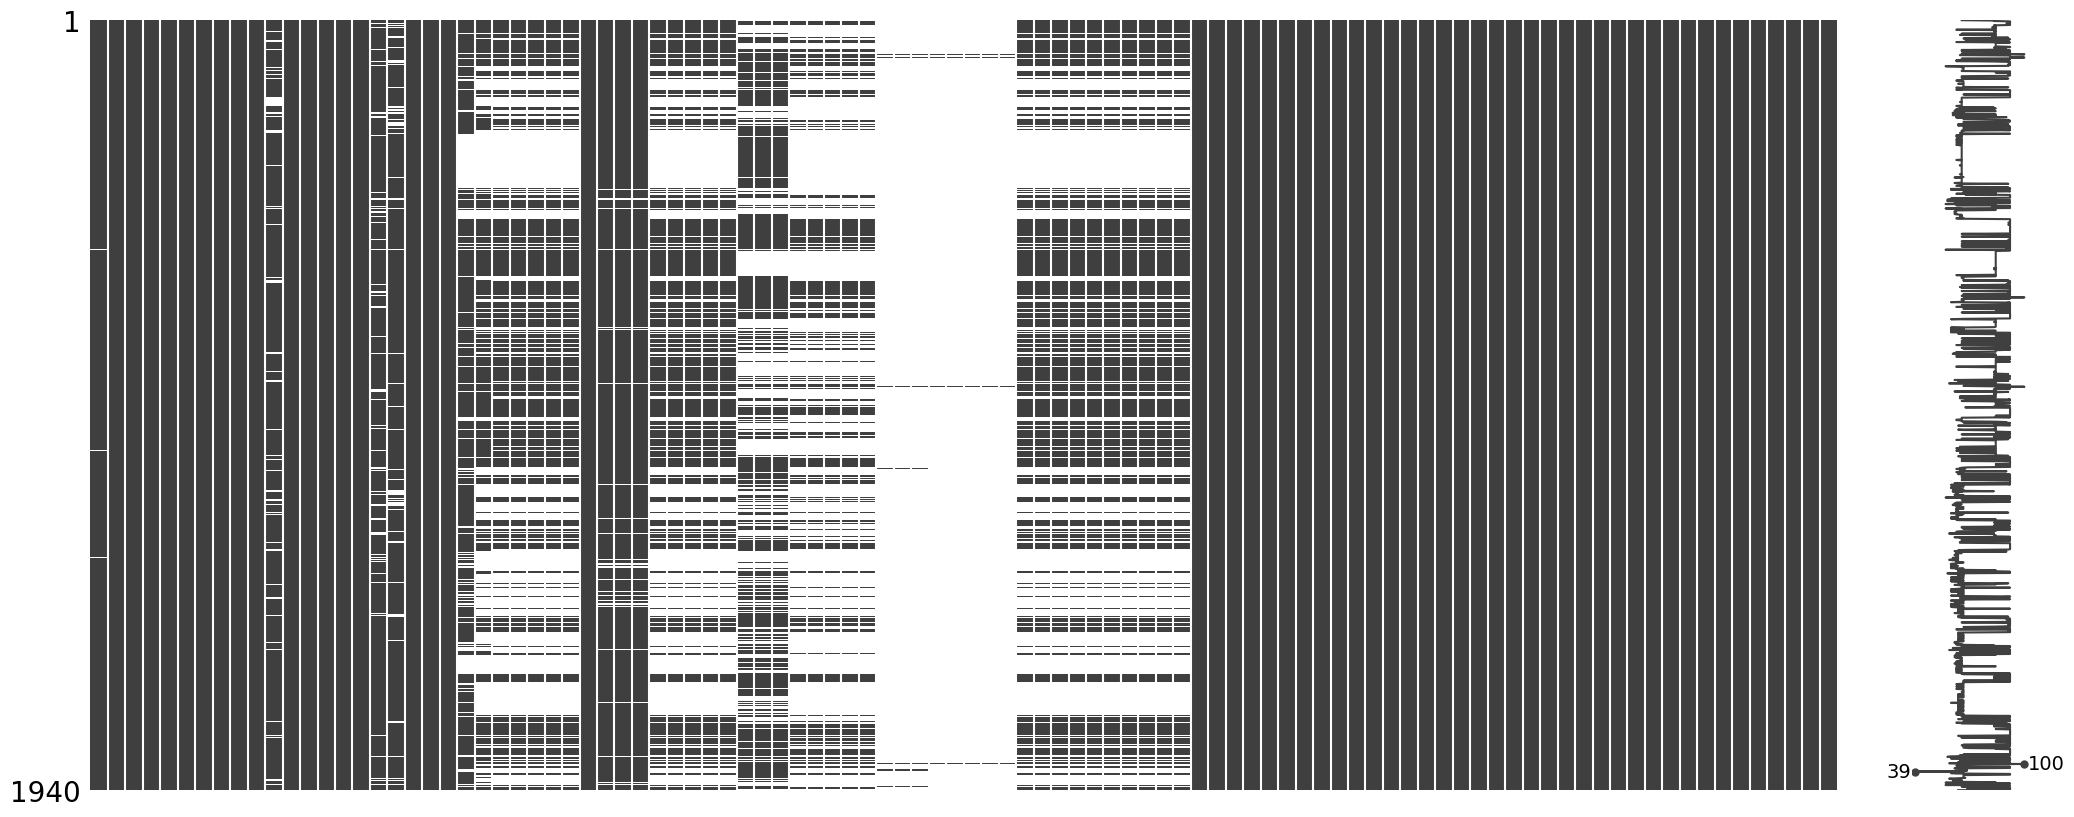

In [49]:
missingno.matrix(data_maize)

The crop production is the outcome the treatment affects. Let's see how does the treatment seems to affect the crop production:

In [50]:
data_maize.previousadvice.value_counts()

previousadvice
no     1701
yes     239
Name: count, dtype: int64

Text(0.5, 0, 'Maize yield (kg/ha)')

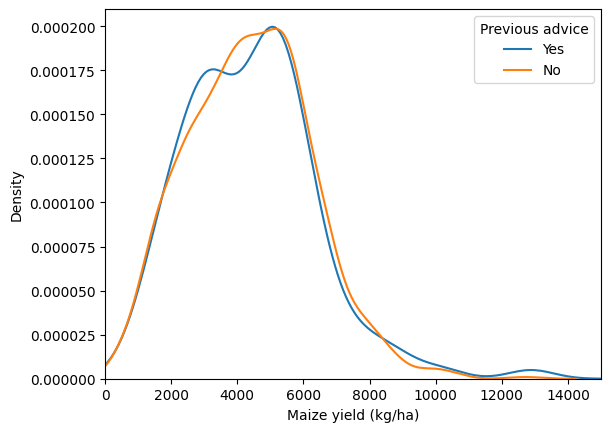

In [51]:
fig, ax = plt.subplots(1, 1)

sns.kdeplot(
    data_maize.loc[data_maize.previousadvice == 'yes'],
    x='maizeprodkg_ha', ax=ax, label='Yes'
)
sns.kdeplot(
    data_maize.loc[data_maize.previousadvice == 'no'],
    x='maizeprodkg_ha', ax=ax, label='No'
)
ax.legend(title='Previous advice')
ax.set_xlim(0, 15000)
ax.set_xlabel('Maize yield (kg/ha)')

Just by looking at the distribution of yield, we could venture to say that the previous advice does not have any effect on yield.